In [180]:
import csv
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score
import seaborn as sns


In [181]:
#1.Regresion
#Realizar la exploración de los datos correlación, scatter plots, boxplots e histogramas
#¿Qué variables son importantes para predecir el valor?

In [182]:
est_train_raw = pd.read_csv("training_pruebas.csv", low_memory=False)
remove_colums = [
    "ESTU_SNIES_PRGMACADEMICO", "ESTU_PRESENTACIONSABADO", "ESTU_DEPTO_PRESENTACION", "FAMI_EDUCACIONPADRE",
    "ESTU_ESTUDIANTE", "ESTU_COD_DEPTO_PRESENTACION", "ESTU_COD_MCPIO_PRESENTACION", "ESTU_TIPODOCUMENTOSB11",
    "ESTU_PRGM_MUNICIPIO", "ESTU_INST_CODMUNICIPIO", "ESTU_NUCLEO_PREGRADO_1", "ESTU_DEPTO_RESIDE",
    "ESTU_INST_DEPARTAMENTO", "ESTU_PRGM_CODMUNICIPIO", "ESTU_ESTADOINVESTIGACION", "ESTU_COD_RESIDE_MCPIO",
    "ESTU_CONSECUTIVO", "ESTU_TIPODOCUMENTO", "ESTU_INST_MUNICIPIO", "ESTU_PRGM_ACADEMICO",
    "ESTU_NACIONALIDAD", "FAMI_TRABAJOLABORMADRE", "ESTU_PAIS_RESIDE", "FAMI_CUANTOSCOMPARTEBAÑO",
    "INST_CARACTER_ACADEMICO", "ESTU_MCPIO_RESIDE", "PERIODO", "ESTU_MCPIO_PRESENTACION",
    "FAMI_EDUCACIONMADRE", "INST_ORIGEN", "ESTU_DEPTO_PRESENTACION", "GRUPOREFERENCIA",
    "ESTU_PRESENTACIONCASA", "ESTU_COD_RESIDE_DEPTO", "ESTU_PRGM_DEPARTAMENTO", "ESTU_NUCLEO_PREGRADO",
    "ESTU_ESTADOCIVIL", "INST_NOMBRE_INSTITUCION", "FAMI_TRABAJOLABORPADRE"
]
est_train = est_train_raw.drop(columns = remove_colums)

In [183]:
##1.2 Existen nulos?, ¿cómo se deben imputar?

In [184]:
continu_colums = ["ESTU_INSE_INDIVIDUAL", "ESTU_NSE_IES","ESTU_NSE_INDIVIDUAL"]
categorica_colums = [col for col in est_train.columns if (col not in continu_colums) and (col != "PUNT_GLOBAL")]

def delete_nulls(data):
    new_data = data.copy()
    mean = new_data[continu_colums].mean()
    mode = new_data[categorica_colums].mode()
    for col in new_data[continu_colums]:
        for i, val in enumerate(new_data[col]):
            if math.isnan(val):
                new_data.loc[i, col] = mean[col]
    new_data[categorica_colums] = new_data[categorica_colums].apply(lambda x: x.fillna(x.value_counts().index[0]))

    return new_data

est_train = delete_nulls(est_train)

for i, val in enumerate(est_train["PUNT_GLOBAL"]):
    if math.isnan(val):
        est_train.loc[i, col] = est_train["PUNT_GLOBAL"].mean()

In [185]:
#1.3 Crear dummy variables para incluirlas en la correlación

In [186]:
def data_transformation(data):
    
    data["ESTU_FECHANACIMIENTO"] = pd.to_datetime(data["ESTU_FECHANACIMIENTO"], format="mixed", dayfirst=True, errors='coerce')
    today = pd.to_datetime('today', format="%d/%m/%Y")
    data["ESTU_FECHANACIMIENTO"] = data["ESTU_FECHANACIMIENTO"].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))
    age_mean = data["ESTU_FECHANACIMIENTO"].mean()

    for i, val in enumerate(data["ESTU_FECHANACIMIENTO"]):
        if str(val) == 'nan':
            data.loc[i, "ESTU_FECHANACIMIENTO"] = age_mean
            
    data["ESTU_SIMULACROTIPOICFES"] = data["ESTU_SIMULACROTIPOICFES"].apply(lambda x: 1 if x == 'Si' else 0)
    data["FAMI_TIENEHORNOMICROOGAS"] = data["FAMI_TIENEHORNOMICROOGAS"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_PRIVADO_LIBERTAD"] = data["ESTU_PRIVADO_LIBERTAD"].apply(lambda x: 1 if x == 'S' else 0)
    data["FAMI_TIENEMOTOCICLETA"] = data["FAMI_TIENEMOTOCICLETA"].apply(lambda x: 1 if x == 'Si' else 0)
    data["FAMI_TIENECONSOLAVIDEOJUEGOS"] = data["FAMI_TIENECONSOLAVIDEOJUEGOS"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_PAGOMATRICULACREDITO"] = data["ESTU_PAGOMATRICULACREDITO"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_METODO_PRGM"] = data["ESTU_METODO_PRGM"].apply(lambda x: 1 if x == 'DISTANCIA VITUAL' else 0)
    data["FAMI_TIENEINTERNET"] = data["FAMI_TIENEINTERNET"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_ACTIVIDADREFUERZOGENERIC"] = data["ESTU_ACTIVIDADREFUERZOGENERIC"].apply(lambda x: 1 if x == 'Si' else 0)
    data["FAMI_TIENEAUTOMOVIL"] = data["FAMI_TIENEAUTOMOVIL"].apply(lambda x: 1 if x == 'Si' else 0)
    data["FAMI_TIENESERVICIOTV"] = data["FAMI_TIENESERVICIOTV"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_PAGOMATRICULAPADRES"] = data["ESTU_PAGOMATRICULAPADRES"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_PAGOMATRICULABECA"] = data["ESTU_PAGOMATRICULABECA"].apply(lambda x: 1 if x == 'Si' else 0)
    data["FAMI_TIENELAVADORA"] = data["FAMI_TIENELAVADORA"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_PAGOMATRICULAPROPIO"] = data["ESTU_PAGOMATRICULAPROPIO"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_GENERO"] = data["ESTU_GENERO"].apply(lambda x: 1 if x == 'F' else 0)
    data["ESTU_ACTIVIDADREFUERZOAREAS"] = data["ESTU_ACTIVIDADREFUERZOAREAS"].apply(lambda x: 1 if x == 'Si' else 0)
    data["FAMI_TIENECOMPUTADOR"] = data["FAMI_TIENECOMPUTADOR"].apply(lambda x: 1 if x == 'Si' else 0)
    data["ESTU_AREARESIDE"] = data["ESTU_AREARESIDE"].apply(lambda x: 1 if x == 'Cabecera Municipal' else 0)
    data["ESTU_EXTERIOR"] = data["ESTU_EXTERIOR"].apply(lambda x: 1 if x == 'SI' else 0)

data_transformation(est_train)
print(np.nonzero(pd.isnull(est_train)))
est_train


#dummies
def normalizar(data):
    for i, col in enumerate(data.columns):
        data[col] = 0 if data[col].std() == 0 else (data[col] - data[col].mean()) / data[col].std()

est_train_dumm = pd.get_dummies(est_train)
normalizar(est_train_dumm)
est_train_dumm

(array([], dtype=int64), array([], dtype=int64))


,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_EXTERIOR,ESTU_AREARESIDE,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,ESTU_SIMULACROTIPOICFES,ESTU_ACTIVIDADREFUERZOAREAS,...,ESTU_PAGOMATRICULA_Creditos,ESTU_PAGOMATRICULA_Familiares,ESTU_VLRULTIMOSEMESCURSADO_Entre 3 y 5 millones,ESTU_VLRULTIMOSEMESCURSADO_Entre 5 y 7 millones,ESTU_VLRULTIMOSEMESCURSADO_Entre 500 mil y un millon de pesos,ESTU_VLRULTIMOSEMESCURSADO_Entre un millon y 3 millones de pesose,ESTU_VLRULTIMOSEMESCURSADO_Mas de 7 millones,ESTU_VLRULTIMOSEMESCURSADO_Menos de 500 mil pesos,ESTU_VLRULTIMOSEMESCURSADO_No pago semestre,ESTU_NIVEL_PRGM_ACADEMICO_UNIVERSITARIO
0,-1.141938,-0.709521,-0.123835,0.37177,1.534565,-0.617858,-0.834938,-0.942998,0.075645,0.098651,...,-0.547684,1.485369,-0.456533,-0.273497,-0.239647,-0.704445,-0.276743,2.582217,-0.453214,0
1,-1.141938,-0.853080,-0.123835,0.37177,1.534565,-0.617858,-0.834938,-0.942998,0.075645,0.098651,...,-0.547684,-0.673227,-0.456533,-0.273497,-0.239647,-0.704445,-0.276743,2.582217,-0.453214,0
2,0.875696,-0.135285,-0.123835,0.37177,1.534565,-0.617858,-0.834938,-0.942998,0.075645,0.098651,...,-0.547684,-0.673227,-0.456533,-0.273497,-0.239647,-0.704445,-0.276743,2.582217,-0.453214,0
3,0.875696,0.008274,-0.123835,0.37177,1.534565,-0.617858,1.197683,-0.942998,0.075645,0.098651,...,-0.547684,-0.673227,-0.456533,-0.273497,-0.239647,-0.704445,-0.276743,-0.387261,2.206445,0
4,0.875696,2.448775,-0.123835,0.37177,-0.651645,-0.617858,-0.834938,1.060439,0.075645,0.098651,...,-0.547684,-0.673227,2.190403,-0.273497,-0.239647,-0.704445,-0.276743,-0.387261,-0.453214,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111425,0.875696,-0.709521,-0.123835,0.37177,1.534565,-0.617858,1.197683,-0.942998,0.075645,0.098651,...,-0.547684,1.485369,-0.456533,-0.273497,-0.239647,1.419545,-0.276743,-0.387261,-0.453214,0
111426,0.875696,-0.709521,-0.123835,0.37177,1.534565,-0.617858,1.197683,-0.942998,0.075645,0.098651,...,-0.547684,1.485369,2.190403,-0.273497,-0.239647,-0.704445,-0.276743,-0.387261,-0.453214,0
111427,-1.141938,4.458600,-0.123835,0.37177,-0.651645,-0.617858,-0.834938,1.060439,0.075645,0.098651,...,1.825854,-0.673227,-0.456533,-0.273497,-0.239647,1.419545,-0.276743,-0.387261,-0.453214,0
111428,0.875696,-0.853080,-0.123835,0.37177,-0.651645,1.618480,-0.834938,-0.942998,0.075645,0.098651,...,1.825854,-0.673227,2.190403,-0.273497,-0.239647,-0.704445,-0.276743,-0.387261,-0.453214,0


In [187]:
#1.4 Crear una correlación, que variables tienen un efecto positivo en el puntaje y cuales un efecto negativo

In [188]:
est_train_dumm.corrwith(est_train_dumm["PUNT_GLOBAL"]).sort_values(ascending=False).iloc[1:]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


ESTU_NSE_IES                                                         0.262818
ESTU_VALORMATRICULAUNIVERSIDAD_Más de 7 millones                     0.244534
ESTU_INSE_INDIVIDUAL                                                 0.238292
ESTU_NSE_INDIVIDUAL                                                  0.215721
ESTU_VLRULTIMOSEMESCURSADO_Mas de 7 millones                         0.213380
                                                                       ...   
ESTU_PAGOMATRICULAPROPIO                                            -0.165790
ESTU_VLRULTIMOSEMESCURSADO_Entre un millon y 3 millones de pesose   -0.185439
INST_COD_INSTITUCION                                                -0.205356
ESTU_FECHANACIMIENTO                                                -0.252624
ESTU_NIVEL_PRGM_ACADEMICO_UNIVERSITARIO                                   NaN
Length: 108, dtype: float64

In [189]:
#negativo en la parte de abajo

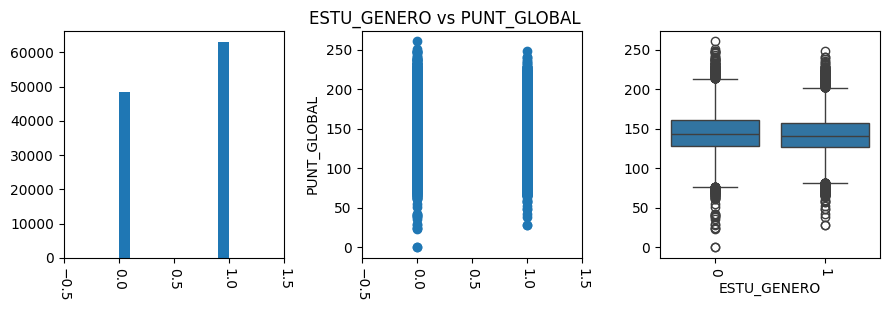

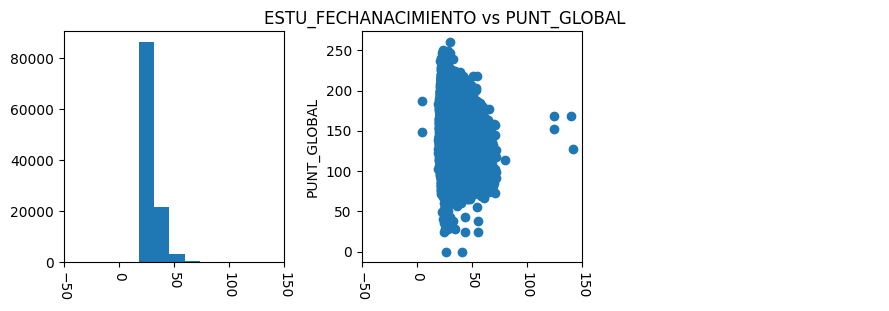

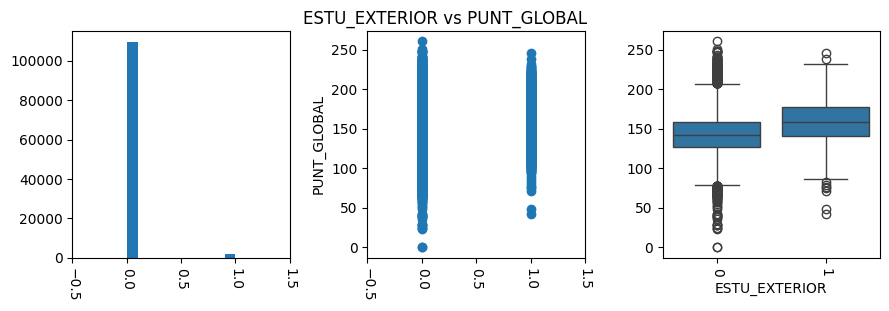

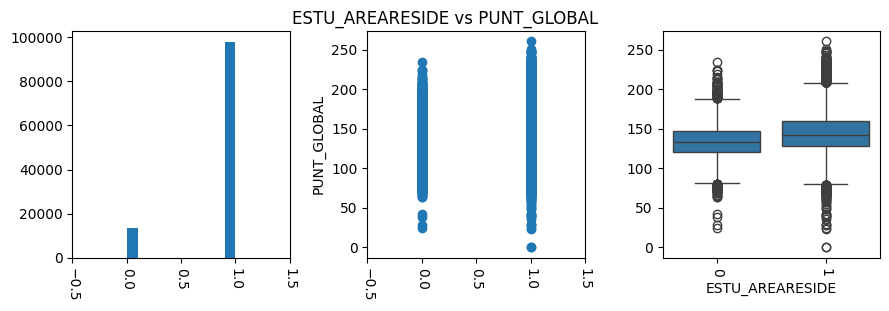

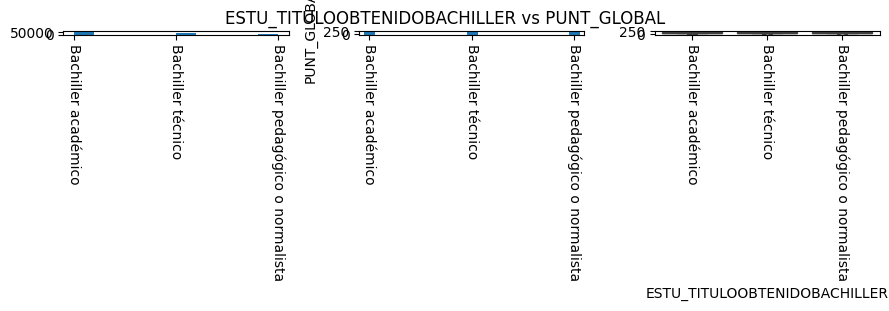

/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_77137/1097818805.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  d.tight_layout()


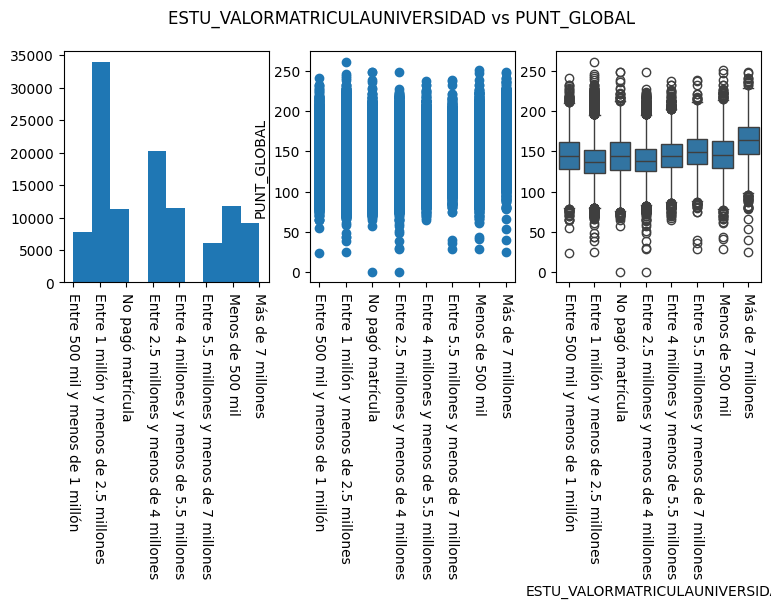

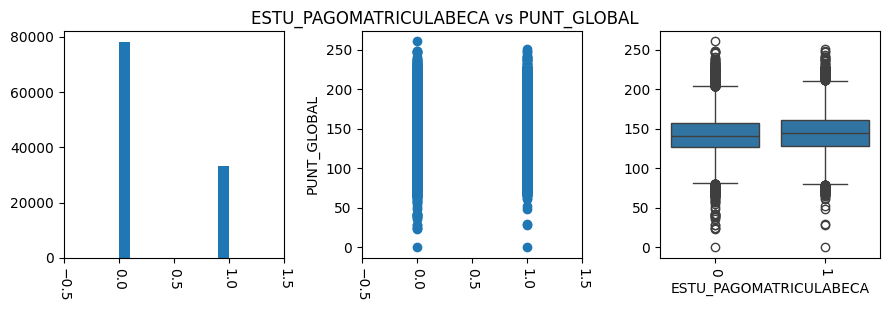

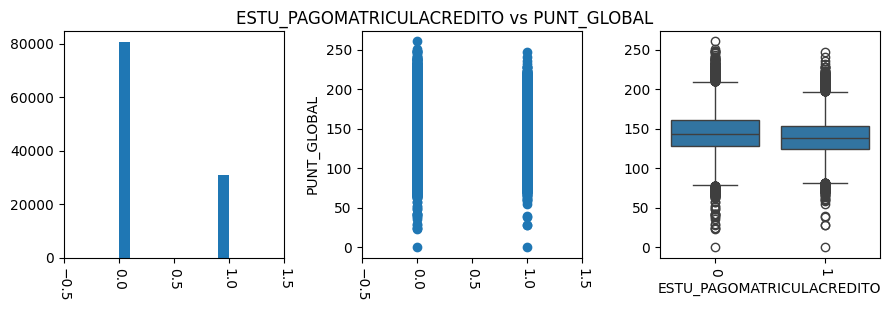

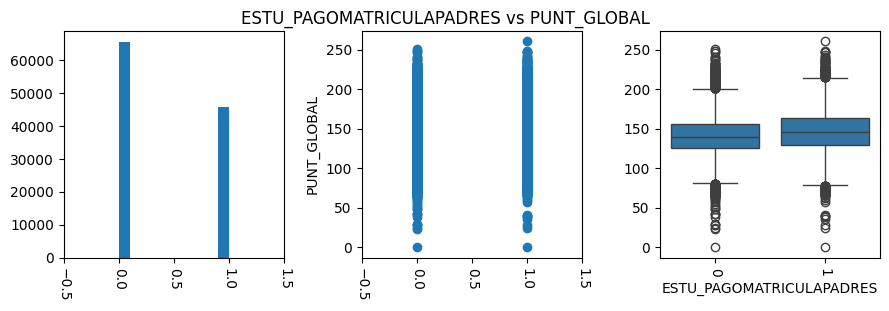

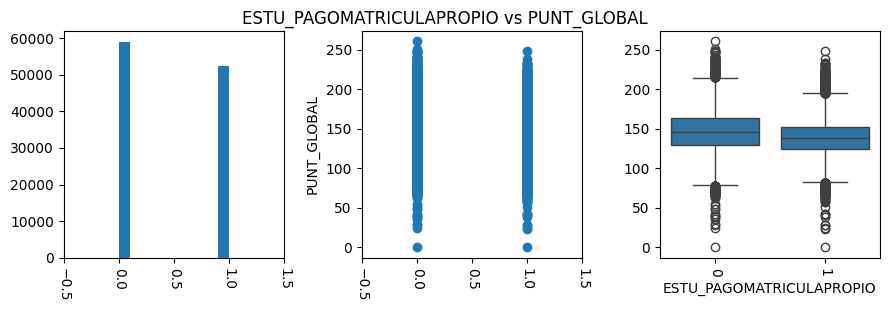

/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_77137/1097818805.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  d.tight_layout()


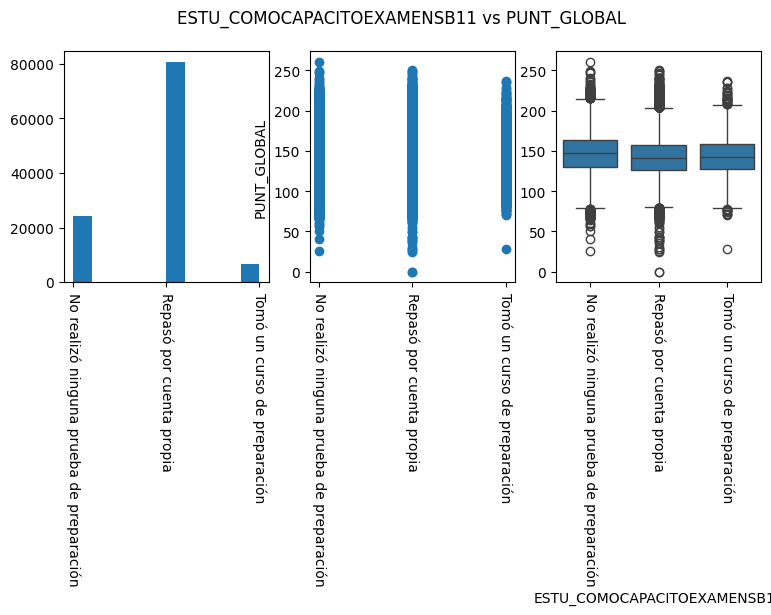

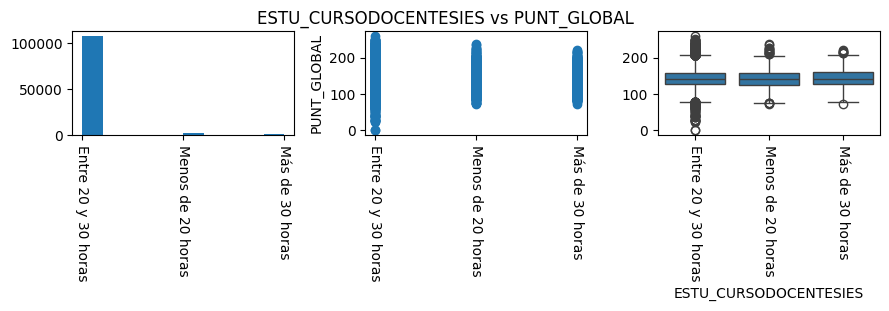

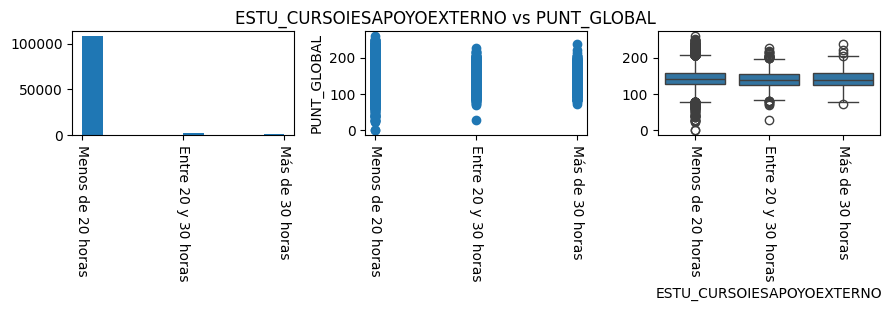

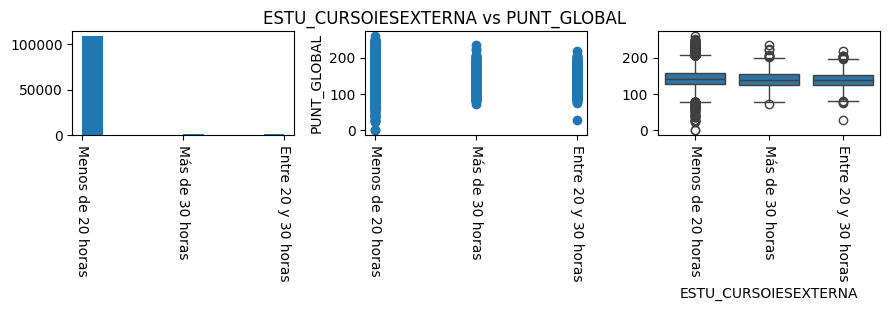

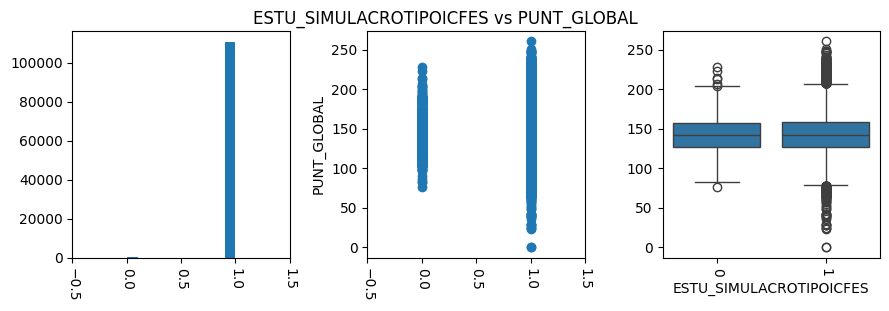

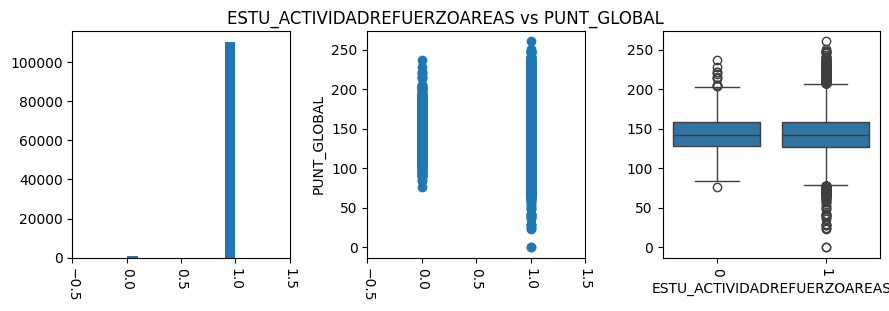

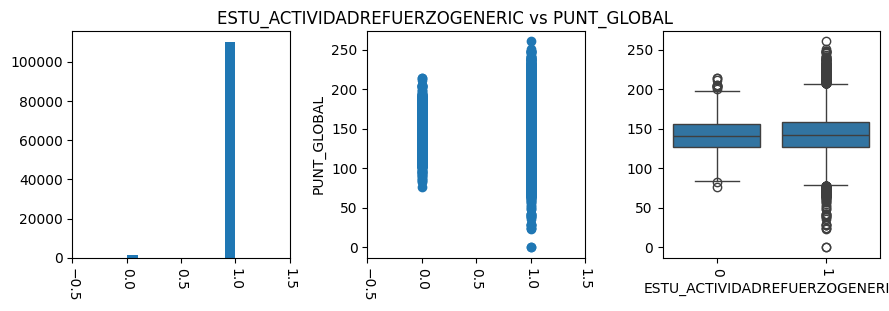

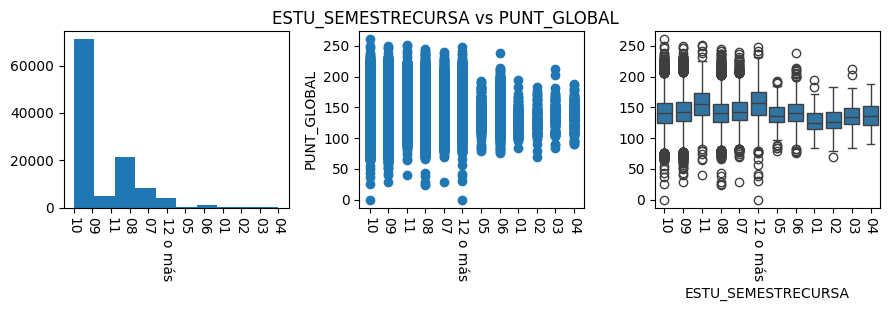

/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_77137/1097818805.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  d.tight_layout()


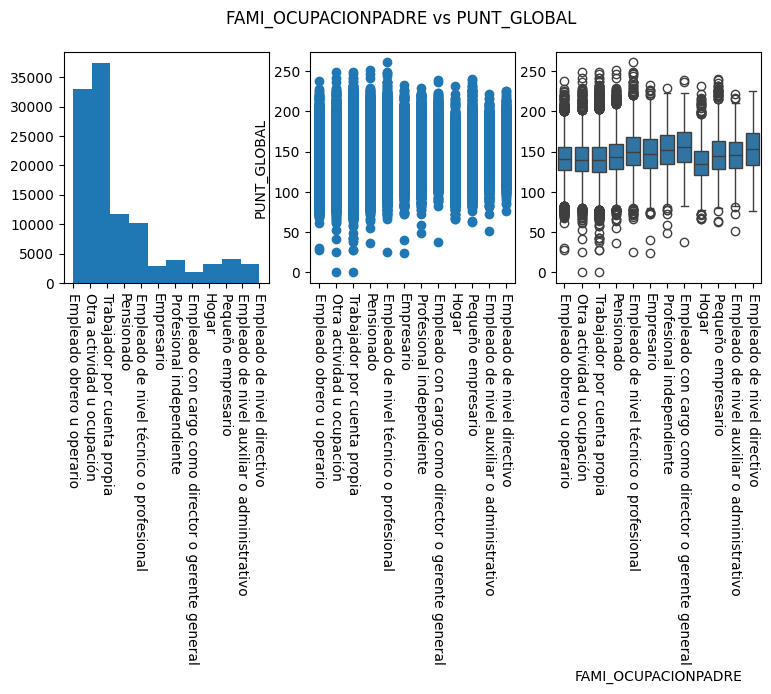

/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_77137/1097818805.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  d.tight_layout()


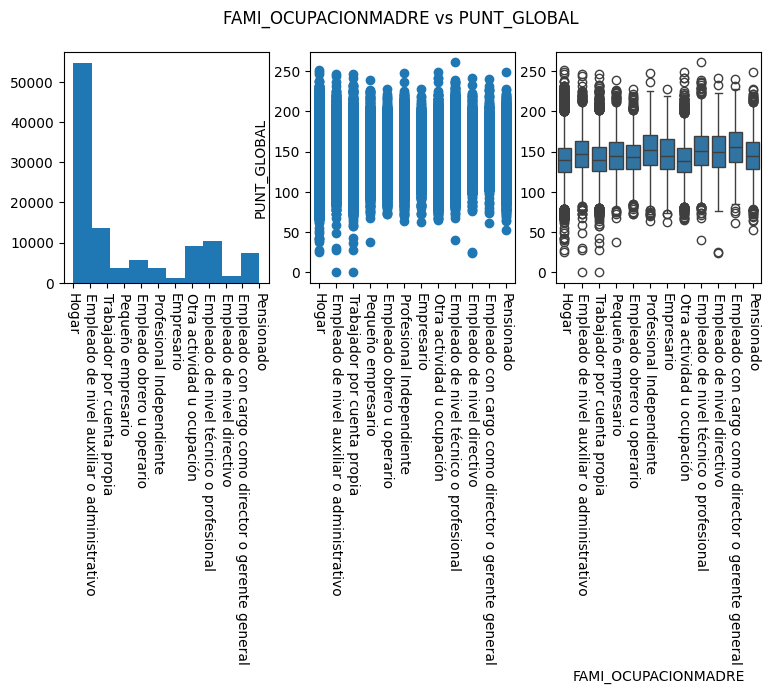

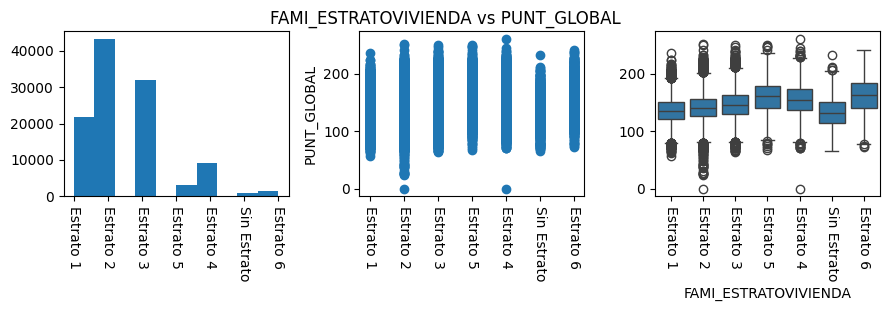

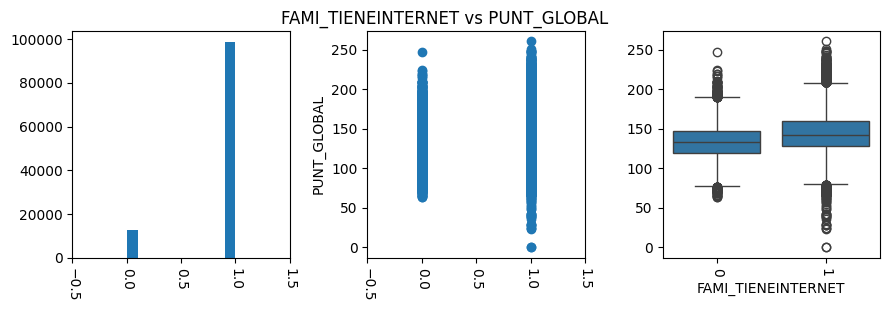

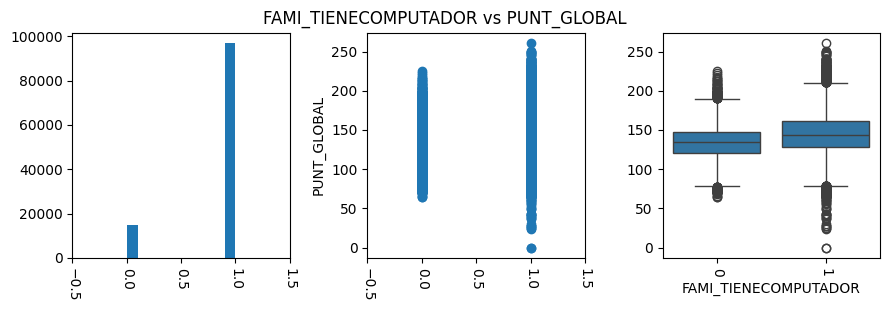

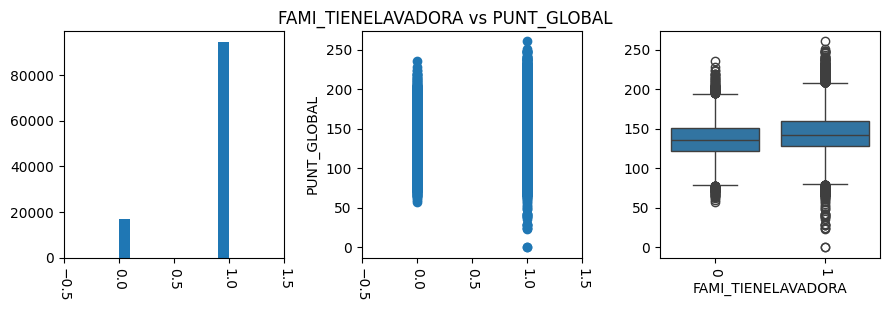

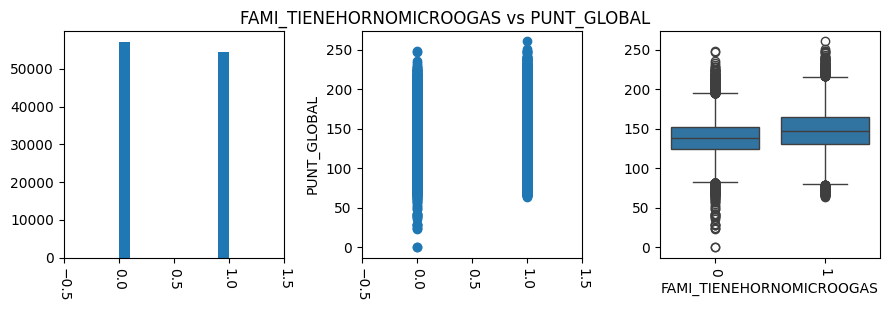

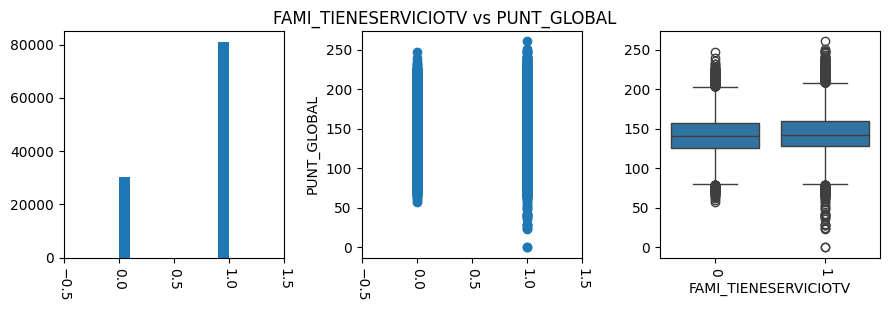

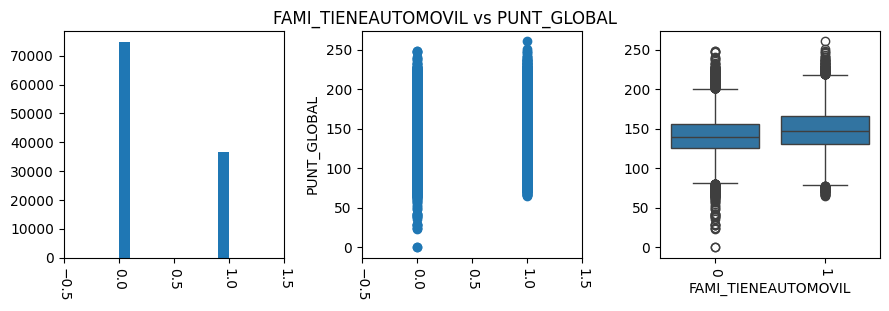

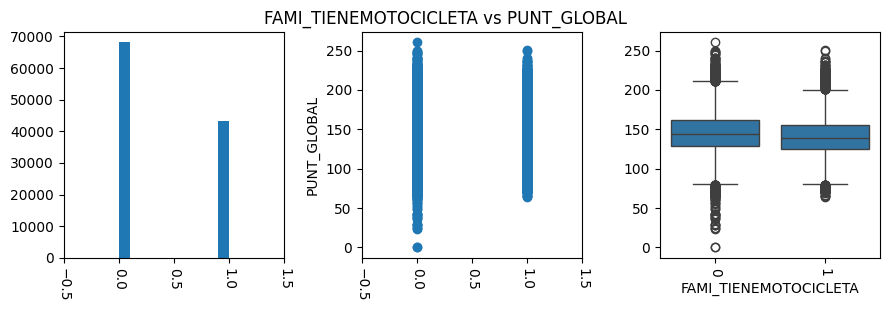

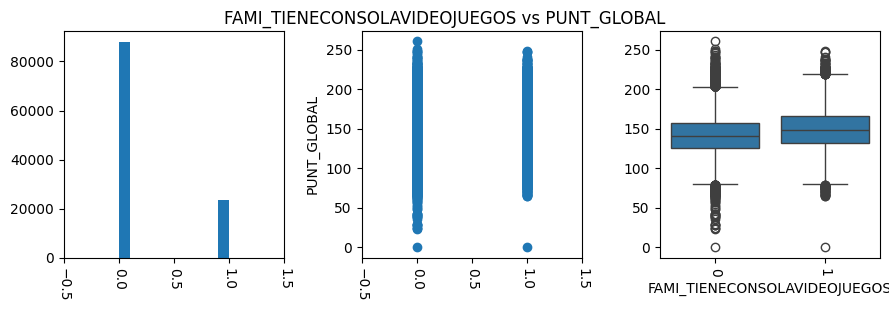

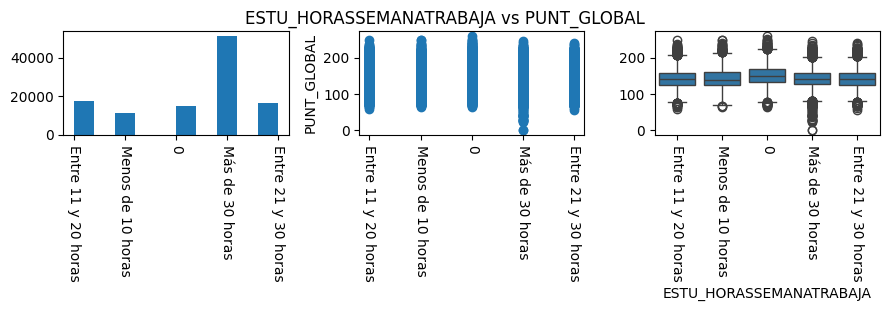

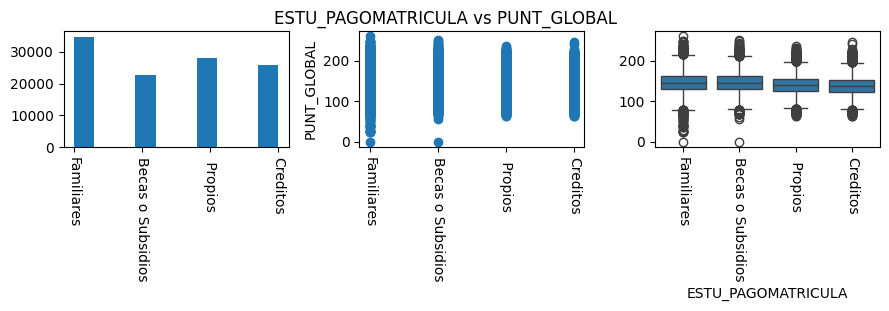

/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_77137/1097818805.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  d.tight_layout()


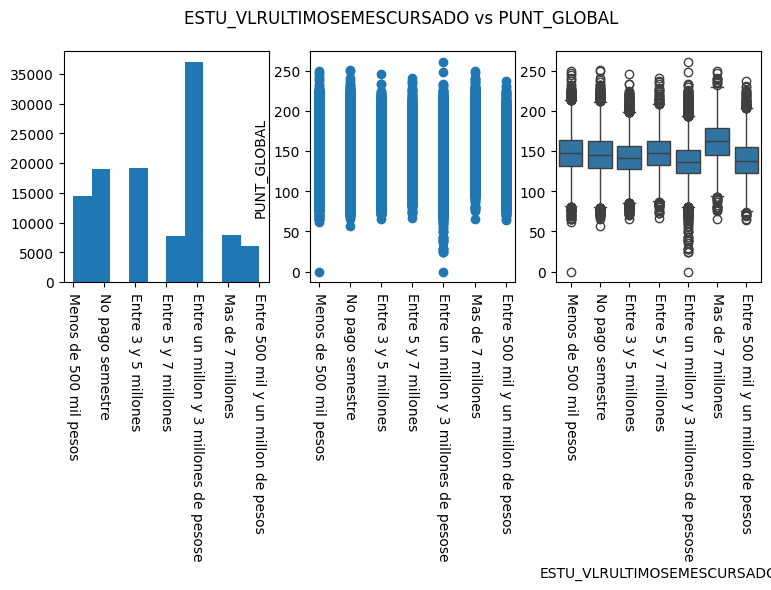

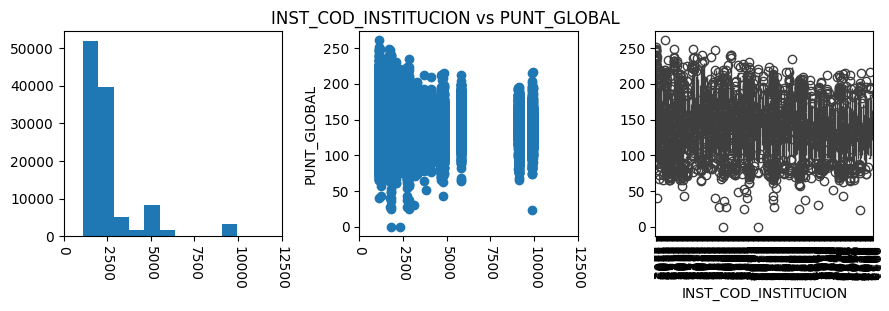

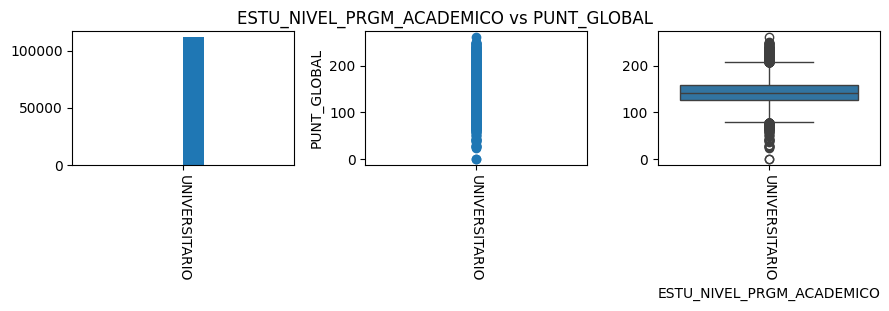

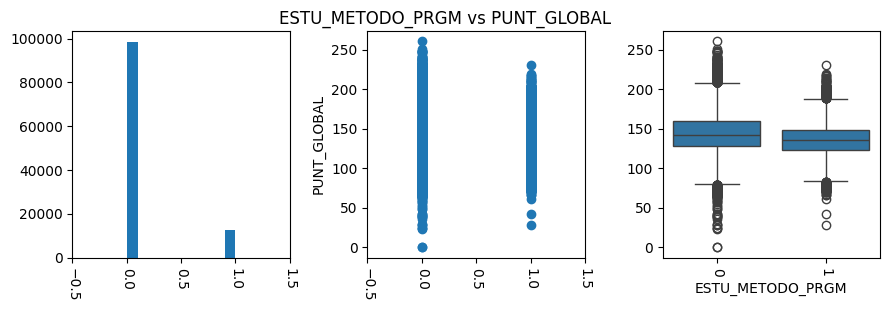

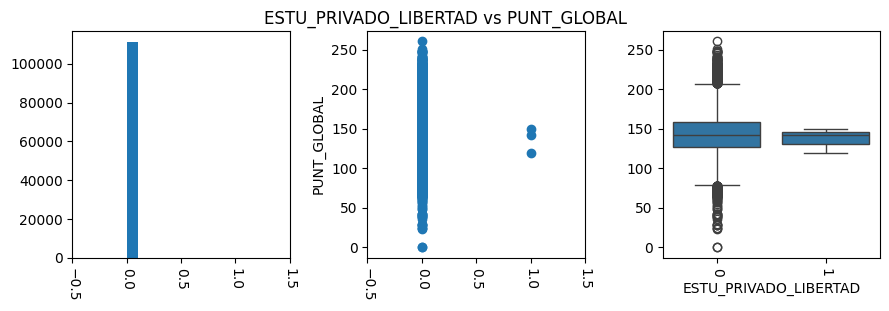

In [190]:
for col in categorica_colums:
    d, ax = plt.subplots(ncols=3, figsize=(9, 3))  # mejor así para que figure y subplots estén sincronizados

    ax[0].hist(est_train[col])
    ax[0].set_xticks(ax[0].get_xticks())
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-90)

    ax[1].scatter(est_train[col], est_train["PUNT_GLOBAL"])
    ax[1].set_xticks(ax[1].get_xticks())
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=-90)
    ax[1].set_ylabel("PUNT_GLOBAL")

    if col != "ESTU_FECHANACIMIENTO":
        sns.boxplot(x=est_train[col], y=est_train["PUNT_GLOBAL"], ax=ax[2])
        ax[2].set_xlabel(col)
        ax[2].set_ylabel("")
        ax[2].set_xticks(ax[2].get_xticks())
        ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=-90)
    else:
    
        ax[2].axis('off')

    d.tight_layout()
    plt.suptitle(f"{col} vs PUNT_GLOBAL", y=1.02)
    plt.show()


In [191]:
#2 Traning / Testing

In [192]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], est_train["PUNT_GLOBAL"]
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

#### 2.1 Aplique las transformaciones más importantes a los datos. (Hint calcular la edad basada en la fecha de nacimiento, agrupar variables categóricas con mucha cardinalidad en grupos).
[Ver 1.3](#13-crear-dummy-variables-para-incluirlas-en-la-correlación)

#### 2.2 Entrenar un modelos de regresión

In [193]:
#2.2 Entrenar un modelos de regresión
reg = LinearRegression()
reg.fit(xr, yr)

LinearRegression()

In [194]:
#2.3 ¿Cuál es el mejor R squared? Cuál es el MAPE y el MS

In [195]:
yr_hat = reg.predict(xr)

def get_r2(true, pred):
    SSR, SST = sum((true-pred)**2), sum((true-np.mean(true))**2)
    R2 = 1 - (float(SSR))/SST
    return R2

def get_mape(true, pred):
    return (100/len(true)*sum(abs(pred-true)/true))

def get_mse(true, pred):
    return (1/len(true))*sum((true-pred)**2)

print("Training:")
print("R2   ", get_r2(yr, yr_hat))
print("MAPE ", get_mape(yr, yr_hat))
print("MSE  ", get_mse(yr, yr_hat))

Training:
R2    0.25644895673316204
MAPE  inf
MSE   408.4365371777399


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [196]:
#4. Utilizando los datos de test medir el MAPE y el MSE de test. Qué tan diferentes son las métricas de training. (El menor error del grupo tiene un +1)

In [197]:
ys_hat = reg.predict(xs)

print("Testing:")
print("R2   ", get_r2(ys, ys_hat))
print("MAPE ", get_mape(ys, ys_hat))
print("MSE  ", get_mse(ys, ys_hat))

Testing:
R2    0.26363630840823726
MAPE  inf
MSE   407.79585179164104


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [198]:
#5. Describa en palabras que dice el modelo cuales son los principales hallazgos.

In [199]:
est_test_raw = pd.read_csv("test_pruebas.csv", low_memory=False)
est_test = est_test_raw.drop(columns=remove_colums)
est_test = delete_nulls(est_test)
data_transformation(est_test)
est_test_dumm = pd.get_dummies(est_test)
normalizar(est_test_dumm)
est_test_dumm

,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_EXTERIOR,ESTU_AREARESIDE,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,ESTU_SIMULACROTIPOICFES,ESTU_ACTIVIDADREFUERZOAREAS,...,ESTU_PAGOMATRICULA_Creditos,ESTU_PAGOMATRICULA_Familiares,ESTU_VLRULTIMOSEMESCURSADO_Entre 3 y 5 millones,ESTU_VLRULTIMOSEMESCURSADO_Entre 5 y 7 millones,ESTU_VLRULTIMOSEMESCURSADO_Entre 500 mil y un millon de pesos,ESTU_VLRULTIMOSEMESCURSADO_Entre un millon y 3 millones de pesose,ESTU_VLRULTIMOSEMESCURSADO_Mas de 7 millones,ESTU_VLRULTIMOSEMESCURSADO_Menos de 500 mil pesos,ESTU_VLRULTIMOSEMESCURSADO_No pago semestre,ESTU_NIVEL_PRGM_ACADEMICO_UNIVERSITARIO
0,0.873960,3.004117,-0.122216,0.362459,-0.653165,1.643914,-0.833058,-0.946695,0.075763,0.09706,...,1.853608,-0.675279,-0.454813,-0.269317,-0.245202,1.425919,-0.275324,-0.391896,-0.454123,0
1,-1.144175,-0.425419,-0.122216,0.362459,1.530951,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,1.853608,-0.675279,-0.454813,3.712968,-0.245202,-0.701277,-0.275324,-0.391896,-0.454123,0
2,0.873960,-0.282522,-0.122216,0.362459,-0.653165,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,-0.539469,-0.675279,-0.454813,-0.269317,-0.245202,-0.701277,-0.275324,-0.391896,2.201967,0
3,0.873960,0.289067,-0.122216,0.362459,-0.653165,-0.608282,1.200354,-0.946695,0.075763,0.09706,...,-0.539469,1.480816,-0.454813,-0.269317,-0.245202,1.425919,-0.275324,-0.391896,-0.454123,0
4,0.873960,0.289067,8.181928,0.362459,-0.653165,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,-0.539469,1.480816,-0.454813,-0.269317,-0.245202,1.425919,-0.275324,-0.391896,-0.454123,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27853,0.873960,0.574862,-0.122216,0.362459,-0.653165,1.643914,-0.833058,1.056269,0.075763,0.09706,...,-0.539469,-0.675279,-0.454813,-0.269317,-0.245202,1.425919,-0.275324,-0.391896,-0.454123,0
27854,-1.144175,-0.711214,-0.122216,0.362459,-0.653165,1.643914,1.200354,-0.946695,0.075763,0.09706,...,-0.539469,-0.675279,2.198627,-0.269317,-0.245202,-0.701277,-0.275324,-0.391896,-0.454123,0
27855,0.873960,3.432809,-0.122216,0.362459,1.530951,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,1.853608,-0.675279,-0.454813,-0.269317,-0.245202,-0.701277,-0.275324,2.551605,-0.454123,0
27856,0.873960,-0.139625,-0.122216,0.362459,-0.653165,-0.608282,1.200354,1.056269,0.075763,0.09706,...,-0.539469,-0.675279,-0.454813,-0.269317,-0.245202,1.425919,-0.275324,-0.391896,-0.454123,0


In [200]:
est_test_pred = reg.predict(est_test_dumm)
output = pd.DataFrame(est_test_pred, columns=["GLOBAL_SCORE"])

with open("Regression.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["id","GLOBAL_SCORE"])
    for i, val in enumerate(np.array(output["GLOBAL_SCORE"])):
        writer.writerow([est_test_raw["ESTU_CONSECUTIVO"][i],val])

output

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,GLOBAL_SCORE
0,123.667603
1,156.528627
2,149.971326
3,132.683722
4,160.253363
...,...
27853,136.285970
27854,153.971881
27855,130.812173
27856,147.417788


In [201]:
#2 Crear un modelo de KNN

In [202]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], est_train["PUNT_GLOBAL"]
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

In [203]:
#2.1 Hacer pruebas con 5, 10, 20 y 30 vecinos. Seleccione el numero de vecinos basado en el error de test MSE

In [ ]:
neightbor_sizes = [5,10,20,30]

for s in neightbor_sizes:
    knn = KNeighborsRegressor(n_neighbors=s)
    knn.fit(xr, yr)
    yr_hat = knn.predict(xr)
    print(f"{s} vecinos:")
    print("MSE(train)   ", get_mse(yr, yr_hat))
    print("MAPE(train)  ", get_mape(yr, yr_hat))

    ys_hat = knn.predict(xs)
    print("MSE(test)    ", get_mse(ys, ys_hat))
    print("MAPE(test)   ", get_mape(ys, ys_hat))

    print("---------------------------------")

5 vecinos:
MSE(train)    329.01302342277666
MAPE(train)   inf
MSE(test)     496.54712913937004
MAPE(test)    inf
---------------------------------


In [ ]:
#el MSE de test mejora entre mas vecinos en este caso es 30 

In [ ]:
knn = KNeighborsRegressor(n_neighbors=30)
knn.fit(xr, yr)
ys_hat = knn.predict(xs)
print("MSE(test)    ", get_mse(ys, ys_hat))
print("MAPE(test)   ", get_mape(ys, ys_hat))

est_test_pred = knn.predict(est_test_dumm)
output = pd.DataFrame(est_test_pred, columns=["GLOBAL_SCORE"])

with open("Knn.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["id","GLOBAL_SCORE"])
    for i, val in enumerate(np.array(output["GLOBAL_SCORE"])):
        writer.writerow([est_test_raw["ESTU_CONSECUTIVO"][i],val])

output

In [ ]:
#2.2 Describa cual es mejor modelo entre la regresión o el knn.

In [ ]:
#yo pensaria que la regresion lineal es mas efectiva

In [ ]:
#3. Crear un modelo de GBM

In [ ]:
x.columns = [col.replace(" ", "_") for col in x.columns]

if y.dtype.kind in 'if' and len(y.unique()) > 10:
    from lightgbm import LGBMRegressor
    gbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)
else:
    from lightgbm import LGBMClassifier
    gbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)

# Entrenamiento
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)
gbm.fit(xr, yr)

yr_hat = gbm.predict(xr)
ys_hat = gbm.predict(xs)

print("Train: ")
print("MSE(train)    ", get_mse(yr, yr_hat))
print("MAPE(train)   ", get_mape(yr, yr_hat))

print("Test: ")
print("MSE(test)    ", get_mse(ys, ys_hat))
print("MAPE(test)   ", get_mape(ys, ys_hat))


In [ ]:
est_test_pred = gbm.predict(est_test_dumm)
output = pd.DataFrame(est_test_pred, columns=["GLOBAL_SCORE"])

with open("GBM.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["id","GLOBAL_SCORE"])
    for i, val in enumerate(np.array(output["GLOBAL_SCORE"])):
        writer.writerow([est_test_raw["ESTU_CONSECUTIVO"][i],val])

output

In [ ]:
#4. Crear un modelo de regresión logística

In [ ]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], (est_train["PUNT_GLOBAL"] > 172).astype(int)

In [ ]:
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

lgr = LogisticRegression()
lgr.fit(xr, yr)

yr_hat = lgr.predict(xr)

print("Regresión logítisca")
print("MSE(train):", get_mse(yr_hat, yr))

ys_hat = lgr.predict(xs)

print("MSE(test):", get_mse(ys_hat, ys))

In [ ]:
importance = pd.DataFrame({'Variable': est_test_dumm.columns, 'Coeficiente': lgr.coef_[0]}).sort_values(ascending=False, by=["Coeficiente"]).iloc[1:]
importance

In [ ]:
confusion_m = pd.DataFrame(metrics.confusion_matrix(yr, yr_hat))
confusion_m

In [ ]:
pre_r, acc_r, rec_r = precision_score(yr, yr_hat), accuracy_score(yr, yr_hat), recall_score(yr, yr_hat)
print("RECALL:", rec_r)
print("PRECISION:",pre_r)
print("ACCURACY:",acc_r)

In [ ]:
confusion_s = pd.DataFrame(metrics.confusion_matrix(ys, ys_hat))
confusion_s

In [179]:
pre_s, acc_s, rec_s = precision_score(ys, ys_hat), accuracy_score(ys, ys_hat), recall_score(ys, ys_hat)
print("RECALL:", rec_s)
print("PRECISION:",pre_s)
print("ACCURACY:",acc_s)

RECALL: 0.17518796992481203
PRECISION: 0.6099476439790575
ACCURACY: 0.8881809207574262
